In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

MY_SEED = 202672288  # TODO: 랜덤한 숫자
np.random.seed(MY_SEED)

#  Titanic 데이터를 사용
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


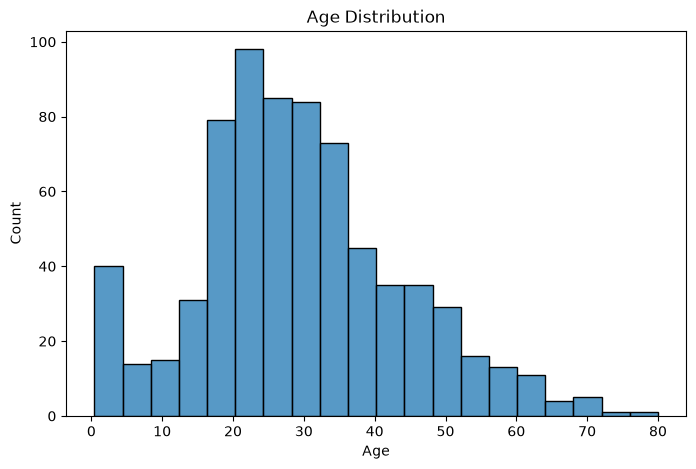

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(data=titanic, x="age", bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()


## 1. 필수 과제

### 1-1. ML 문제 정의 (수업 §2)

코드를 짜기 전에, 이 문제를 ML 문제로 **정식화**합니다. 아래 빈칸을 채우세요.

- 우리는 이 데이터셋에서 타이타닉 탑승자의 생존 여부를 맞춰야합니다. **target(label)**은 어떤 column인가? → `survived`
- 이 데이터에는 label이 있다. 따라서 학습 방식은 `지도`학습이다.
- target이 `범주형`이므로, 이 문제는 `분류` 문제다.
- 학습 전에 데이터를 train/test로 나누는 이유를 **본인의 언어로** 한 문장: test 데이터가 학습과정에서 사용되는 데이터 누수를 방지하기 위해 분리시킨다.

In [26]:
# 사용할 feature와 target 선택
features = ["pclass", "sex", "age", "fare"]
target = "survived"

df = titanic[features + [target]].copy()

# [빈칸] age의 결측치를 중앙값으로 채우는 이유 (평균이 아니라 중앙값을 쓰는 이유 포함): age는 이상치와 분포의 치우침으로 인해 평균보다 중앙값을 사용하는 것이 원래 데이터의 분포를 최대한 왜곡하지 않는다.
df["age"] = df["age"].fillna(df["age"].median())

# [빈칸] sex를 0/1 숫자로 바꾸는 이유 (모델 입장에서 설명): ML모델은 문자열을 직접 계산할 수 없으므로 모델이 연산하고 학습할 수 있도록 숫자 형태로 변환해야한다.
df["sex"] = (df["sex"] == "female").astype(int)

df = df.dropna()

X = df[features]
y = df[target]

# TODO: train/test를 8:2로 분할하세요. random_state=MY_SEED 사용
# [빈칸] stratify=y 옵션을 주는 이유: survived는 생존(1)과 사망(0) 비율이 동일하지 데이터이므로 `stratify=y`를 사용해서 train셋과 test셋 모두에 원본데이터의 생존/사망 비율을 유지한채 분할시켜준다.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=MY_SEED,
    stratify=y
)

print(f"train: {X_train.shape}, test: {X_test.shape}")
print(f"train 생존율: {y_train.mean():.3f}, test 생존율: {y_test.mean():.3f}")

#MY_SEED = 202110156
# train: (712, 4), test: (179, 4)
#train 생존율: 0.383, test 생존율: 0.385

train: (712, 4), test: (179, 4)
train 생존율: 0.383, test 생존율: 0.385


### 1-3. Gradient Descent 손계산 (수업 §3)

수업에서 "학습 = loss를 낮추는 방향으로 파라미터를 조금씩 갱신"이라고 했습니다. 이걸 **가장 작은 예제로 직접 계산**합니다.

**설정**: 데이터 3개 $(x, y) = (1,2), (2,4), (3,6)$, 모델 $\hat{y} = wx$ (절편 없음), loss는 MSE

$$L(w) = \frac{1}{3}\sum_{i=1}^{3}(y_i - wx_i)^2, \qquad \frac{\partial L}{\partial w} = -\frac{2}{3}\sum_{i=1}^{3} x_i(y_i - wx_i)$$

**문제**: $w_0 = 0$, learning rate $\eta = 0.1$에서 시작하여 **gradient descent를 3회 반복해 직접 계산**하고, **각 단계에서 $w$가 왜 그 방향으로, 왜 그만큼 움직였는지** 설명하세요. (계산기는 써도 되지만 코드로 먼저 답을 구하면 안 됩니다 — 아래 검증 셀은 손계산이 끝난 뒤에 실행)

| 반복 | 현재 $w$ | 각 데이터의 오차 $(y_i - wx_i)$ | gradient $\frac{\partial L}{\partial w}$ | 갱신된 $w$ |
|---|---|---|---|---|
| 1 | 0 | 2, 4, 6 | -56/3 |28/15 |
| 2 | 28/15  | 2/15, 4/15, 2/5 | -56/45 |448/225 |
| 3 | 448/225 | 2/225, 4/225, 6/225 | -56/675 | 6748/3375 |

**서술**: 매 반복마다 gradient의 크기가 어떻게 변했고, 그것이 $w$의 이동량과 어떤 관계인가? 이 과정이 언제, 왜 멈추게 될까? → gradient값은 매 반복마다 점점 작아졌다. gradient descent 갱신식 $$w_{\text{new}} = w_{\text{current}} - \eta \frac{\partial L}{\partial w}$$ 에 따라 각 단계에서 계산된 gradient 값이 음수이므로 새로운 w값은 계속 증가하되, 그 증가폭은 점점 감소하였다. 주어진 $\eta$ 값과 갱신식에 따라 가중치의 이동량이 결정되었다.


In [20]:
# ===== 손계산 검증용 셀 (표를 다 채운 뒤에 실행하세요) =====
# 주의: 위에서 만든 target y(Series)를 덮어쓰지 않도록 여기서는 gx, gy 라는 별도 변수를 쓴다.
gx = np.array([1, 2, 3])
gy = np.array([2, 4, 6])

w = 0.0
lr = 0.1

for step in range(1, 4):
    # TODO: 위 수식대로 gradient를 코드로 옮기세요
    grad = -2/len(gx) * np.sum(gx*(gy - w * gx))   # 힌트: -2/len(gx) * np.sum(...)

    # [빈칸] gradient의 '반대 방향'으로 이동하는 이유: Loss를 감소시키기 위해 가중치를 gradient의 반대방향으로 갱신한다.
    w = w - lr * grad

    loss = np.mean((gy - w * gx) ** 2)
    print(f"step {step}: grad = {grad:+.4f}, w = {w:.4f}, loss = {loss:.4f}")


# 손계산 결과와 출력이 일치하는지 확인하고, 다르면 어디서 틀렸는지 찾아 적으세요: 손계산 결과와 일치한다. (분수로 작성했다는 점이 다르다.)

#MY_SEED = 202110156
# step 1: grad = -18.6667, w = 1.8667, loss = 0.0830
# step 2: grad = -1.2444, w = 1.9911, loss = 0.0004
# step 3: grad = -0.0830, w = 1.9994, loss = 0.0000

step 1: grad = -18.6667, w = 1.8667, loss = 0.0830
step 2: grad = -1.2444, w = 1.9911, loss = 0.0004
step 3: grad = -0.0830, w = 1.9994, loss = 0.0000


In [25]:
# 과정 확인 장치: train과 test 성능을 모두 기록합니다
results = {}

# TODO: 모델 A — LogisticRegression을 학습시키세요 (max_iter=1000)
model_a = LogisticRegression(max_iter=1000)
model_a.fit(X_train, y_train)

# TODO: 모델 B — DecisionTreeClassifier를 학습시키세요 (random_state=MY_SEED)
model_b = DecisionTreeClassifier(random_state=MY_SEED)
model_b.fit(X_train, y_train)

for name, model in [("Logistic Regression", model_a), ("Decision Tree", model_b)]:
    # [빈칸] train 정확도와 test 정확도를 '둘 다' 기록하는 이유 (수업 §3의 개념과 연결해서): 학습에서 gradient descent로 train loss를 계속 감소시키게 되는데, loss만 줄인다고 해서 좋은 모델은 아니다. train accuracy와 test accuracy를 비교하여 loss를 줄인 결과가 새로운 데이터에서도 잘 일반화되는지 확인해야 한다.
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = (train_acc, test_acc)
    print(f"{name:20s} | train acc: {train_acc:.4f} | test acc: {test_acc:.4f}")


#MY_SEED = 202110156
# Logistic Regression  | train acc: 0.7851 | test acc: 0.7933
# Decision Tree        | train acc: 0.9803 | test acc: 0.7654

Logistic Regression  | train acc: 0.7949 | test acc: 0.8045
Decision Tree        | train acc: 0.9789 | test acc: 0.7989


In [ ]:
y_pred = model_a.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# sklearn의 confusion_matrix 배치: [[TN, FP], [FN, TP]]
TN, FP = cm[0]
FN, TP = cm[1]
print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")

# TODO: 아래 4개 지표를 TP/TN/FP/FN '만으로' 직접 계산하세요 (sklearn 함수 사용 금지)
my_accuracy  = (TP+TN)/(TP+TN+FP+FN)
my_precision = TP/(TP+FP) # [빈칸] precision의 분모에 들어가는 것과 그 의미: 모델이 positive 라고 예측한 전체 개수
my_recall    = TP/(TP+FN)   # [빈칸] recall의 분모에 들어가는 것과 그 의미: 데이터에서의 진짜 positive 개수
my_f1        = 2 * my_precision * my_recall / (my_precision + my_recall)  # 힌트: precision과 recall의 조화평균

# 검증: sklearn과 비교 (통과하지 못하면 수식을 다시 확인)
assert np.isclose(my_accuracy,  accuracy_score(y_test, y_pred))
assert np.isclose(my_precision, precision_score(y_test, y_pred))
assert np.isclose(my_recall,    recall_score(y_test, y_pred))
assert np.isclose(my_f1,        f1_score(y_test, y_pred))
print("✅ 4개 지표 모두 sklearn과 일치")

#MY_SEED = 202110156
# Confusion Matrix:
#  [[89 21]
#  [16 53]]
# TP=53, TN=89, FP=21, FN=16
# ✅ 4개 지표 모두 sklearn과 일치

Confusion Matrix:
 [[89 21]
 [16 53]]
TP=53, TN=89, FP=21, FN=16
✅ 4개 지표 모두 sklearn과 일치


### 1-6. 결과 해석 (필수 서술)

아래 4개 질문에 **본인의 실험 결과 수치를 근거로** 답하세요. (수치 없이 일반론만 쓰면 감점)

1. **왜 이러한 결과가 나왔는가?** — 두 모델의 test 정확도는 각각 얼마였고, 이 데이터에서 그 정도 성능이 나온 이유를 feature 관점에서 추측하면? → `두 모델의 test 정확도는 각각 LogisticRegression: 0.7933, DecisionTree: 0.7654이었고, 사용한 feature인 pclass, sex, age, fare 만으로도 약 80%의 정확도를 보인 것을 보아 이 변수들이 생존 여부를 예측하는 데 일정 수준의 정보를 제공했을 것으로 추측된다.`
2. **두 모델의 성능 차이는 어디에서 발생했는가?** — train acc와 test acc의 '차이'가 두 모델에서 어떻게 달랐는가? 이를 모델 구조(선형 경계 vs 재귀 분할)의 관점에서 해석하면? → `Logistic Regrssion은 train 정확도 0.7851, test 정확도 0.7933으로 두 성능의 차이가 거의 존재하지 않아 학습데이터와 새로운 데이터간의 비교적 일관된 성능을 보였다. 이는 Logistic Regression이 feature들의 선형 결합으로 단순한 결정 경계를 학습하기 때문에 학습 데이터에 지나치게 적합되지 않고 일반화된 결과로 볼 수 있다. 반면 Decision Tree는 train 정확도 0.9803, test 정확도 0.7654로 큰 차이를 보였다. 이는 feature를 기준으로 데이터를 재귀적으로 계속 분할하여 선형에 비해 복잡한 경계를 만들 수 있으므로 학습 데이터의 세부적인 패턴과 잡음까지도 학습하여 과적합된 결과로 해석할 수 있다.`
3. **실험 조건을 변경하면 결과가 어떻게 달라지는가?** — `MY_SEED`를 다른 값으로 바꿔 1-2 ~ 1-4를 다시 실행해 보고, 어떤 수치가 얼마나 흔들렸는지 기록. 이 흔들림을 줄이는 방법으로 수업에서 배운 것은? → `Logistic Regression의 train acc가 0.7851에서 0.7949로, test acc가 0.7933에서 0.8045로, Decision Tree의 train acc가 0.9803에서 0.9789로, test acc가 0.7654에서 0.7989로 수치가 변화하였다. 분할에 따른 흔들림을 줄이고 싶을때는 교차검증(Cross-Validation)을 사용한다. 데이터를 k개의 부분으로 나눈후 평가용 부분을 바꿔가면서 k번 학습 및 평가한 뒤 평균을 내는 방법이다.`
4. **예상과 다른 결과가 나왔다면 그 원인은 무엇인가?** — 과제를 시작하기 전 예상과 달랐던 지점 하나와, 그 원인에 대한 본인의 가설: → `train, test 셋의 분할 비율 등이 달라져야 모델의 accurracy가 변화할 것이라 예상했었는데 달라지지 않아도 accuracy에 변화가 존재한다. 분한 비율은 달라지지 않았어도 내부에 뽑힌 표본 데이터는 이전과는 다른 새로운 데이터의 집합이기 때문에 모델의 학습 결과에도 변화가 존재할 수 있다.`


## 3. 생성형AI 활용 방법

문제를 풀면서 GPT, Claude 등 생성형 AI를 **어디에, 어떻게** 썼는지 기록하는 곳입니다. (사용하지 않았다면 "사용하지 않음"이라고 적으세요)

- **활용 방법**: 어떤 문제에서, 어떤 목적으로(개념 질문 / 에러 해결 / 코드 초안 등) 사용했는지 → `markdown에 공식 작성`
- **AI 답변 중 그대로 쓰지 않고 직접 수정·검증한 부분**: → `공식 그대로 사용하였음`
- **대화 내역 붙여넣기**: (아래에 전체 대화를 붙여넣으세요)

```
경사하강법 갱신식 markdown 문법으로 작성해줘.

Markdown(LaTeX)으로는 아래처럼 작성하면 됩니다.

$$
w_{\text{new}} = w_{\text{current}} - \eta \frac{\partial L}{\partial w}
$$

또는 반복 횟수를 표시하는 형태(교재에서 가장 많이 사용)

$$
w_{t+1} = w_t - \eta \frac{\partial L}{\partial w}
$$

혹은 손계산에서 바로 사용할 수 있도록

$$
w_{k+1} = w_k - \eta \frac{\partial L}{\partial w}
$$

가장 일반적인 표기입니다.

여기서

w
t
	

 : 현재 가중치
w
t+1
	

 : 다음 가중치
η : Learning Rate(학습률)
∂w
∂L
	

 : Loss를 w로 미분한 Gradient

을 의미합니다. 과제에서는 w
t+1
	

=w
t
	

−η
∂w
∂L
	

 형태를 쓰는 것이 가장 표준적입니다.
```


## 4. 회고

- **가장 어려웠던 부분**과 그것을 어떻게 해결했는지 (또는 아직 해결하지 못했는지, 없다면 없음이라고 적어도 됨): → `없음`
- 이번 과제 내용 중 기술블로그 '과제 복습' 섹션에 정리할 핵심 1가지: → `경사하강법(gradient descent)`
